<a href="https://colab.research.google.com/github/vivpatel27-bit/ml-projects/blob/main/RosevilleOutage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Predicting Power Outage Times in Roseville**

**1.) Data**

The data is downloaded from OpenData Roseville, and can be found here: https://data.roseville.ca.us/Electric/Electric-Outages/36fw-ianb/about_data

The data has not been split into test or train sets yet

**2.) Evaluation**

The evaluation metrics used for this project are RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error) alongside it

**3.) Standard Imports**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

**4.) Importing Data**

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Electric_Outages_20260630.csv",
                 low_memory=False)

**5.) Cleaning Data**

In [5]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3278 entries, 0 to 3277
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   StartDateTime                        3275 non-null   object
 1   TimeOut                              3271 non-null   object
 2   TimeOn                               3271 non-null   object
 3   CustomerCount                        3271 non-null   object
 4   Cause                                3275 non-null   object
 5   Substation                           3275 non-null   object
 6   Feeder                               3275 non-null   object
 7   Total Customer-Minutes Out of Power  3271 non-null   object
 8   TotalCount                           3275 non-null   object
 9   Scheduled                            3275 non-null   object
 10  CityRelated                          3275 non-null   object
 11  TotalCustCount                       3275 n

In [6]:
df.dtypes

,0
StartDateTime,object
TimeOut,object
TimeOn,object
CustomerCount,object
Cause,object
Substation,object
Feeder,object
Total Customer-Minutes Out of Power,object
TotalCount,object
Scheduled,object


In [7]:
df.isna().sum()

,0
StartDateTime,3
TimeOut,7
TimeOn,7
CustomerCount,7
Cause,3
Substation,3
Feeder,3
Total Customer-Minutes Out of Power,7
TotalCount,3
Scheduled,3


In [8]:
df.columns

Index(['StartDateTime', 'TimeOut', 'TimeOn', 'CustomerCount', 'Cause',
       'Substation', 'Feeder', 'Total Customer-Minutes Out of Power',
       'TotalCount', 'Scheduled', 'CityRelated', 'TotalCustCount',
       'Cust. Related?', 'Momentary?', 'All=CustInt', 'All=CustIntMin',
       'ALL=MonCustInt', 'Major?', 'Planned?', 'WO=CustInt', 'WO=CustIntMin',
       'WO=MonCustInt', 'Quarter'],
      dtype='object')

In [9]:
dropped_df = df.dropna().copy()
dropped_df.isna().sum()
print(str(len(df) - len(dropped_df)) + " rows were dropped")
dropped_df.isna().sum()

10 rows were dropped


,0
StartDateTime,0
TimeOut,0
TimeOn,0
CustomerCount,0
Cause,0
Substation,0
Feeder,0
Total Customer-Minutes Out of Power,0
TotalCount,0
Scheduled,0


In [10]:
#Convert to datetime
dropped_df['TimeOut'] = pd.to_datetime(dropped_df['TimeOut'])
dropped_df['TimeOn'] = pd.to_datetime(dropped_df['TimeOn'])

#Calculate duration in minutes - this is your target
dropped_df['duration_minutes'] = (dropped_df['TimeOn'] - dropped_df['TimeOut']).dt.total_seconds() / 60

#Convert numerical columns into dtype: float
cols = [
    "CustomerCount",
    "Feeder",
    "Total Customer-Minutes Out of Power",
    "TotalCount",
    "TotalCustCount",
    "All=CustInt",
    "WO=CustInt",
    'All=CustIntMin',
    'ALL=MonCustInt',
    'WO=CustIntMin',
    'WO=MonCustInt'
]

for col in cols:
  dropped_df[col] = dropped_df[col].astype(str)
  dropped_df[col] = dropped_df[col].str.replace(",", "").astype(int)

5.) **EDA**

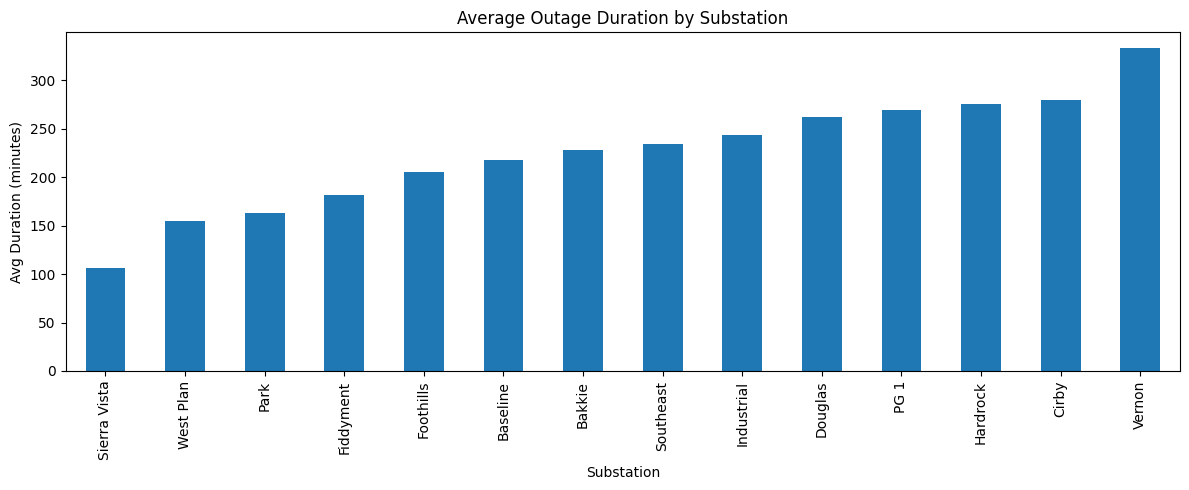

In [11]:
#Average outage duration by substation

fig, ax = plt.subplots(figsize=(12, 5))

dropped_df.groupby('Substation')['duration_minutes'].mean().sort_values().plot(kind='bar', ax=ax)
ax.set_title('Average Outage Duration by Substation')
ax.set_xlabel('Substation')
ax.set_ylabel('Avg Duration (minutes)')

plt.tight_layout()
plt.show()

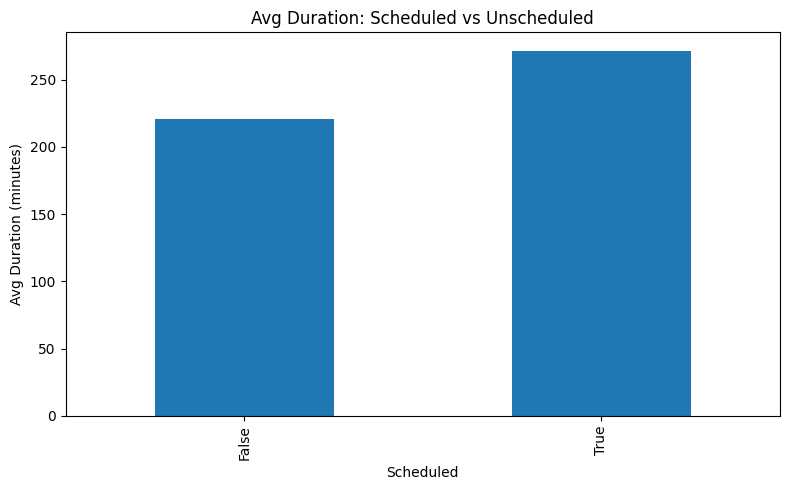

In [12]:
#Average outage duration (shceduled vs. unscheduled)

fig, ax = plt.subplots(figsize=(8, 5))
dropped_df.groupby('Scheduled')['duration_minutes'].mean().plot(kind='bar', ax=ax)
ax.set_title('Avg Duration: Scheduled vs Unscheduled')
ax.set_ylabel('Avg Duration (minutes)')
plt.tight_layout()
plt.show()

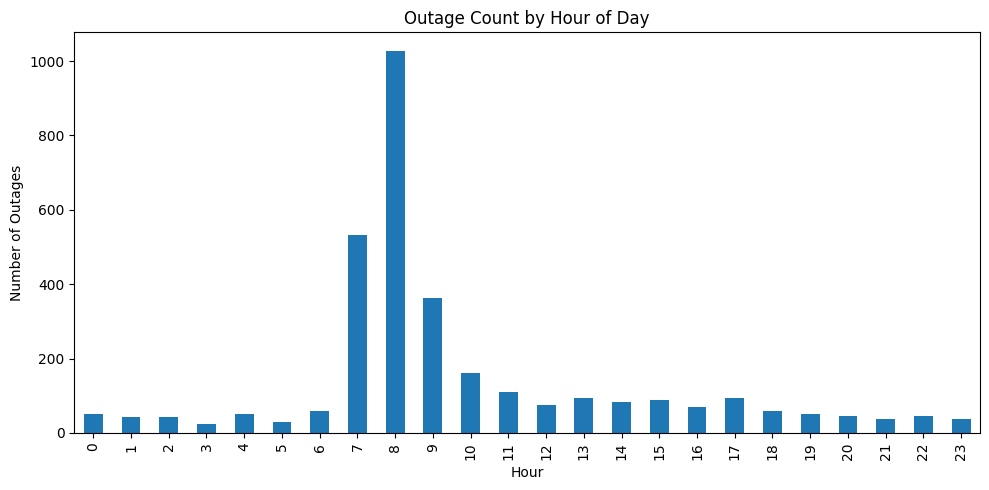

In [13]:
#Outages by hour of day

fig, ax = plt.subplots(figsize=(10, 5))
dropped_df['StartDateTime'] = pd.to_datetime(dropped_df['StartDateTime'])
dropped_df['hour'] = dropped_df['StartDateTime'].dt.hour
dropped_df['hour'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Outage Count by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Outages')
plt.tight_layout()
plt.show()

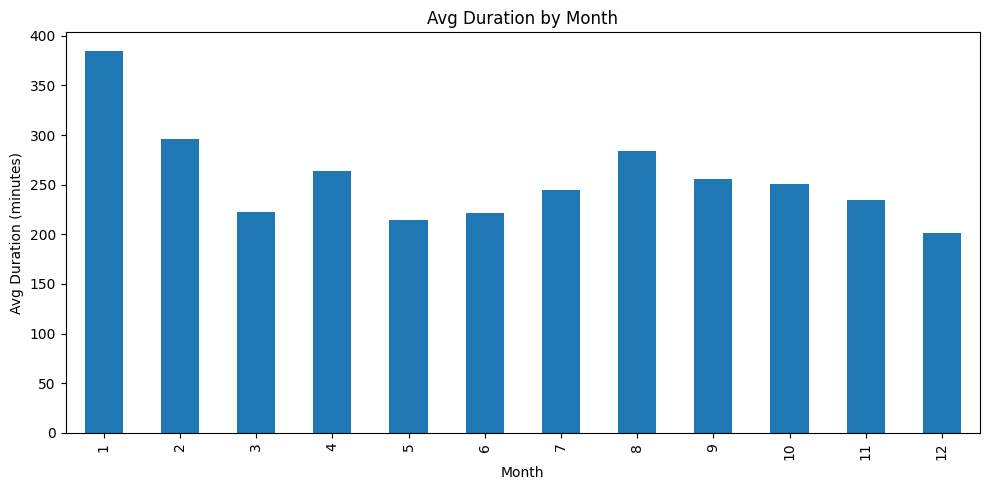

In [14]:
#Outage duration by month

fig, ax = plt.subplots(figsize=(10, 5))
dropped_df['month'] = dropped_df['StartDateTime'].dt.month
dropped_df.groupby('month')['duration_minutes'].mean().plot(kind='bar', ax=ax)
ax.set_title('Avg Duration by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Duration (minutes)')
plt.tight_layout()
plt.show()

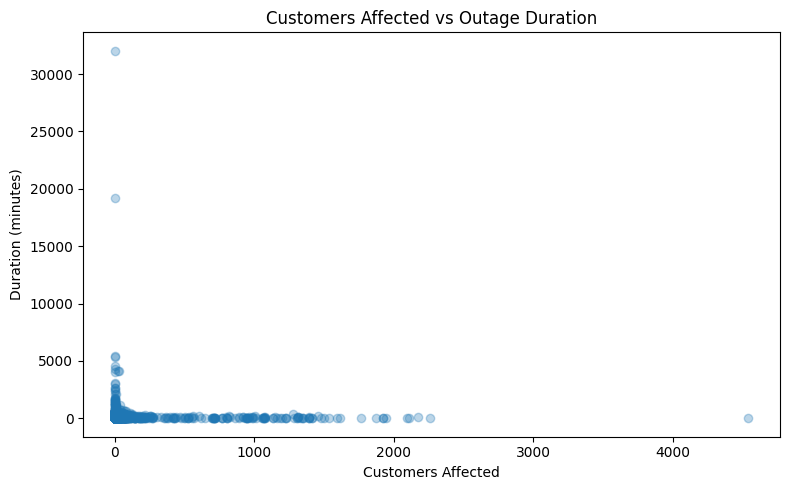

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(dropped_df['CustomerCount'], dropped_df['duration_minutes'], alpha=0.3)
ax.set_xlabel('Customers Affected')
ax.set_ylabel('Duration (minutes)')
ax.set_title('Customers Affected vs Outage Duration')
plt.tight_layout()
plt.show()


**Modelling**

In [16]:
dropped_df.head()

,StartDateTime,TimeOut,TimeOn,CustomerCount,Cause,Substation,Feeder,Total Customer-Minutes Out of Power,TotalCount,Scheduled,...,ALL=MonCustInt,Major?,Planned?,WO=CustInt,WO=CustIntMin,WO=MonCustInt,Quarter,duration_minutes,hour,month
0,2016-07-02 01:25:00,2016-07-02 01:25:00,2016-07-02 05:04:00,107,Unscheduled due to failed cable between T-0743...,Cirby,1,23433,247,False,...,0,False,False,107,23433,0,2016 Sep 01 12:00:00 AM,219.0,1,7
1,2016-07-02 01:25:00,2016-07-02 01:25:00,2016-07-02 05:16:00,36,Unscheduled due to failed cable between T-0743...,Cirby,1,8316,247,False,...,0,False,False,36,8316,0,2016 Sep 01 12:00:00 AM,231.0,1,7
2,2016-07-02 01:25:00,2016-07-02 01:25:00,2016-07-02 06:11:00,95,Unscheduled due to failed cable between T-0743...,Cirby,1,27170,247,False,...,0,False,False,95,27170,0,2016 Sep 01 12:00:00 AM,286.0,1,7
3,2016-07-02 01:25:00,2016-07-02 01:25:00,2016-07-02 10:46:00,9,Unscheduled due to failed cable between T-0743...,Cirby,1,5049,247,False,...,0,False,False,9,5049,0,2016 Sep 01 12:00:00 AM,561.0,1,7
4,2016-07-07 10:00:00,2016-07-07 10:00:00,2016-07-07 11:34:00,3,Scheduled with Customers to replace failing se...,Southeast,1,282,3,True,...,0,False,True,0,0,0,2016 Sep 01 12:00:00 AM,94.0,10,7


In [17]:
dropped_df = dropped_df.drop(columns=['StartDateTime', 'TimeOut', 'TimeOn', 'Cause', 'Quarter'])

# 1. Boolean columns → 0/1 (NaN becomes NaN, then you decide how to fill it — see note below)
bool_cols = ['Scheduled', 'CityRelated', 'Cust. Related?', 'Momentary?', 'Major?', 'Planned?']
for col in bool_cols:
    dropped_df[col] = dropped_df[col].astype('boolean').astype('Int64')  # keeps NaN as <NA>, True/False -> 1/0

# 2. Substation → one-hot encode
dropped_df = pd.get_dummies(dropped_df, columns=['Substation'], drop_first=True)

dropped_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3268 entries, 0 to 3276
Data columns (total 33 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CustomerCount                        3268 non-null   int64  
 1   Feeder                               3268 non-null   int64  
 2   Total Customer-Minutes Out of Power  3268 non-null   int64  
 3   TotalCount                           3268 non-null   int64  
 4   Scheduled                            3268 non-null   Int64  
 5   CityRelated                          3268 non-null   Int64  
 6   TotalCustCount                       3268 non-null   int64  
 7   Cust. Related?                       3268 non-null   Int64  
 8   Momentary?                           3268 non-null   Int64  
 9   All=CustInt                          3268 non-null   int64  
 10  All=CustIntMin                       3268 non-null   int64  
 11  ALL=MonCustInt                     

In [18]:
#Splitting our data
from sklearn.model_selection import train_test_split

#Define features and target
X = dropped_df.drop('duration_minutes', axis=1)
y = dropped_df['duration_minutes']

#Split - 80% train, 20% test
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(2614, 32) (654, 32)


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Put models in a dictionary
models = {"Linear Regression": LinearRegression(),
          "KNN": KNeighborsRegressor(),
          "Random Forest": RandomForestRegressor()}

# Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of differetn Scikit-Learn machine learning models
    X_train : training data (no labels)
    X_test : testing data (no labels)
    y_train : training labels
    y_test : test labels
    """
    # Set random seed
    np.random.seed(42)
    # Make a dictionary to keep model scores
    model_scores = {}
    # Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
    return model_scores


model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)

model_scores

{'Linear Regression': 0.07669773567388027,
 'KNN': 0.3669434272708826,
 'Random Forest': 0.8411297616550675}

**Comapring the Models**

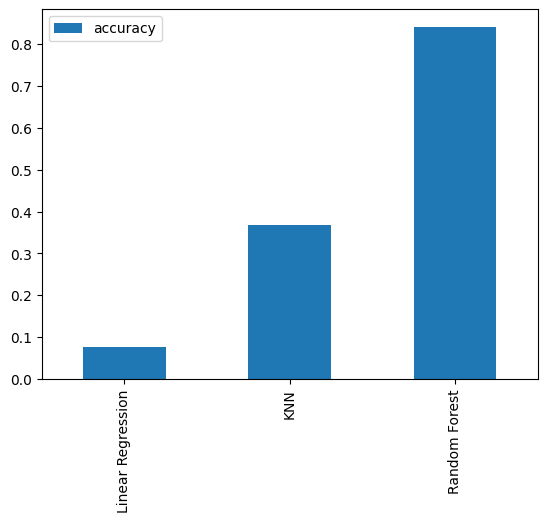

In [20]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar();

**Hyperparameter Tuning for Random Forest**

In [21]:
from sklearn.model_selection import RandomizedSearchCV

# Define a hyperparameter grid for Random Forest
rf_grid = {
    "n_estimators": [100, 200, 300, 500, 1000],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 4, 6, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

np.random.seed(42)

rs_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_grid,
    n_iter=20,          # number of random combinations to try
    cv=5,               # 5-fold cross-validation, all within X_train
    verbose=1,
    n_jobs=-1
)

rs_rf.fit(X_train, y_train)  # X_test never touched here

rs_rf.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': None,
 'max_depth': None}

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

best_rf = rs_rf.best_estimator_

preds = best_rf.predict(X_test)
rmse = sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = best_rf.score(X_test, y_test)

print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.3f}")

print("Tuned Score: " + str(best_rf.score(X_test, y_test)))

RMSE: 156.29, MAE: 18.60, R2: 0.841
Tuned Score: 0.8411297616550675
